# Sales Forecasting Project

Machine Learning project using Online Retail dataset.

## Problem Statement
The objective of this project is to predict future sales using historical retail data to support business decision-making such as inventory planning and demand forecasting.

## 1. Import Libraries
We import required libraries for data analysis, visualization, and modeling.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose

sns.set(style="whitegrid")



>## 2. Load Dataset



In [65]:
df = pd.read_csv(r"C:\Users\kkara\OneDrive\Documents\Future intern\Online Retail.csv", encoding='ISO-8859-1')
df.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


## Data Understanding
We analyze the dataset structure, data types, and summary statistics.

In [66]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ï»¿InvoiceNo  541909 non-null  object 
 1   StockCode     541909 non-null  object 
 2   Description   540455 non-null  object 
 3   Quantity      541909 non-null  int64  
 4   InvoiceDate   541909 non-null  object 
 5   UnitPrice     541909 non-null  float64
 6   CustomerID    406829 non-null  float64
 7   Country       541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [67]:
df.head().columns

Index(['ï»¿InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [68]:
df.head().info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ï»¿InvoiceNo  5 non-null      object 
 1   StockCode     5 non-null      object 
 2   Description   5 non-null      object 
 3   Quantity      5 non-null      int64  
 4   InvoiceDate   5 non-null      object 
 5   UnitPrice     5 non-null      float64
 6   CustomerID    5 non-null      float64
 7   Country       5 non-null      object 
dtypes: float64(2), int64(1), object(5)
memory usage: 452.0+ bytes


In [69]:
df.isnull().sum()

ï»¿InvoiceNo         0
StockCode            0
Description       1454
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      135080
Country              0
dtype: int64

## 3. Data Cleaning
- Removed missing values in important columns  
- Converted date column to datetime format  
- Removed invalid transactions (negative or zero values)  
- Created a new Sales column  

In [70]:
# Remove missing important values
df = df.dropna(subset=['InvoiceDate', 'Quantity', 'UnitPrice'])

# Convert date safely
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['InvoiceDate'])

# Remove invalid sales
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create Sales column
df['Sales'] = df['Quantity']*df['UnitPrice']

In [71]:
df['InvoiceDate'].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

## 4. Aggregate Daily Sales

In [72]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['Sales'].sum().reset_index()
daily_sales.columns = ['Date', 'Sales']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales.head()

,Date,Sales
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46


## 5. Feature Engineering

In [73]:
daily_sales['year'] = daily_sales['Date'].dt.year
daily_sales['month'] = daily_sales['Date'].dt.month
daily_sales['day'] = daily_sales['Date'].dt.day
daily_sales['dayofweek'] = daily_sales['Date'].dt.dayofweek

daily_sales['rolling_mean_7'] = daily_sales['Sales'].rolling(window=7).mean()
daily_sales = daily_sales.dropna()

## 6. Visualization

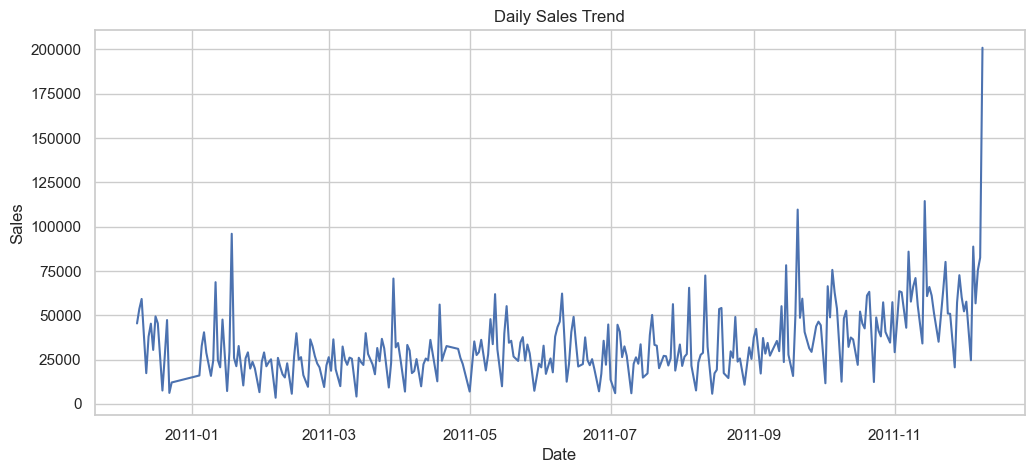

In [74]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Sales', data=daily_sales)
plt.title("Daily Sales Trend")
plt.show()

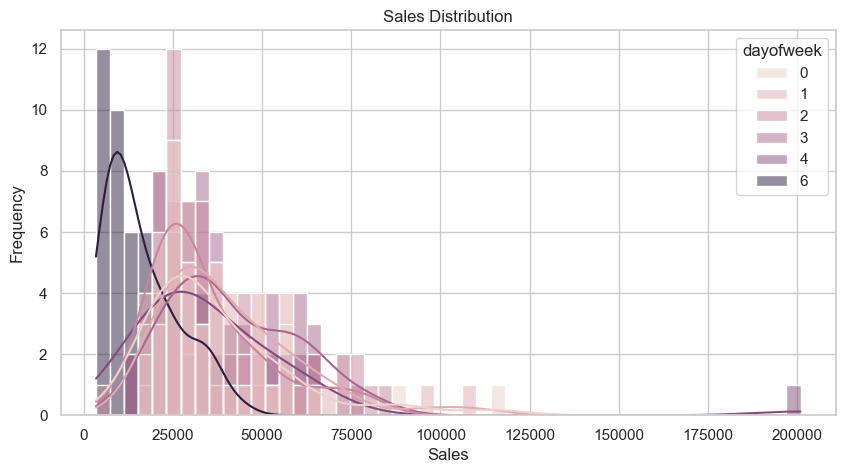

In [75]:
plt.figure(figsize=(10,5))
sns.histplot(data=daily_sales, x='Sales', bins=50, hue='dayofweek', kde=True)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()

## Pair Plot Analysis

- This pair plot visualizes the relationships between key features such as Sales, Month, Day of Week, and Rolling Mean.

- This visualization provides a comprehensive overview of how different variables interact with each other.

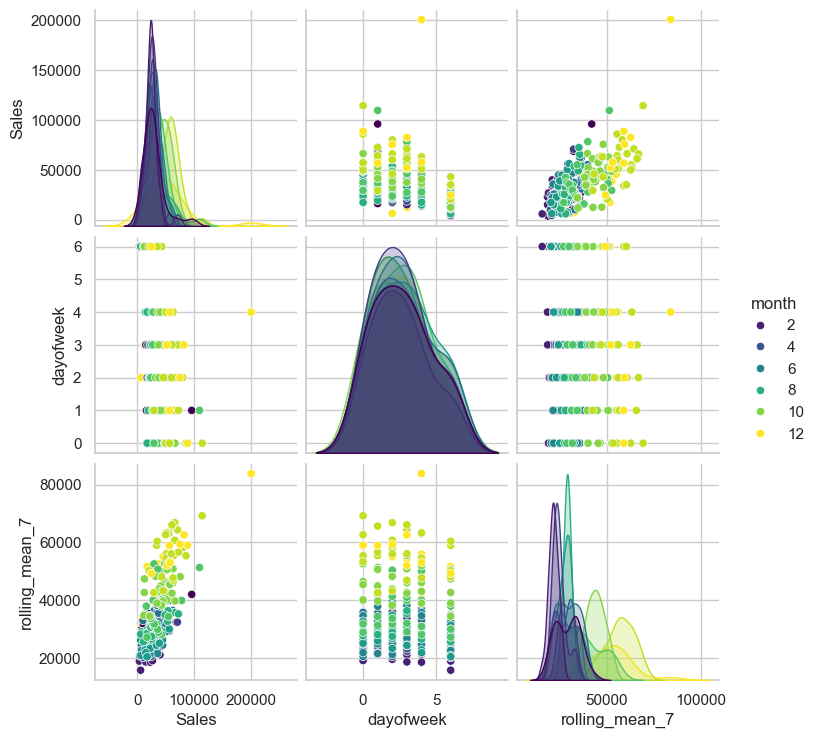

In [76]:
sns.pairplot(
    daily_sales[['Sales','month','dayofweek','rolling_mean_7']],
    hue='month',          # adds colors
    palette='viridis'     # nice color theme
)

plt.show()

## 7. Seasonality Analysis

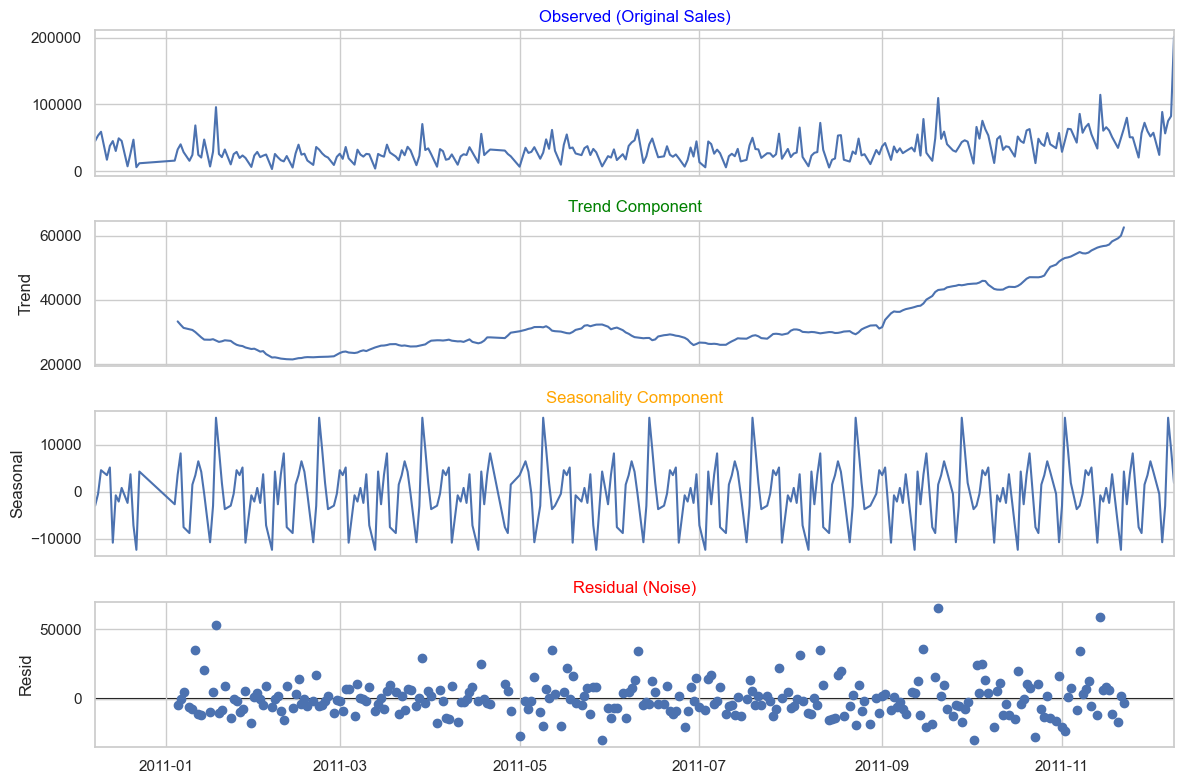

In [77]:
ts = daily_sales.set_index('Date')['Sales']

decomposition = seasonal_decompose(ts, model='additive', period=30)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

# Improve colors manually
axes = fig.axes

axes[0].set_title("Observed (Original Sales)", color='blue')
axes[1].set_title("Trend Component", color='green')
axes[2].set_title("Seasonality Component", color='orange')
axes[3].set_title("Residual (Noise)", color='red')

plt.tight_layout()
plt.show()

## 8. Model Traininng

In [78]:
X = daily_sales[['year','month','day','dayofweek','rolling_mean_7']]
y = daily_sales['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 9. Model Eveluation

In [79]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14042.210817333333
RMSE: 24544.637328652414


### Key Observations

- Rolling mean feature shows strong positive correlation with sales  
- Time-based features (month, day, weekday) have moderate influence on sales  
- Year feature has low correlation, indicating limited impact on short-term predictions  
- No strong negative correlations are observed  
- Features are not highly correlated with each other, reducing multicollinearity issues

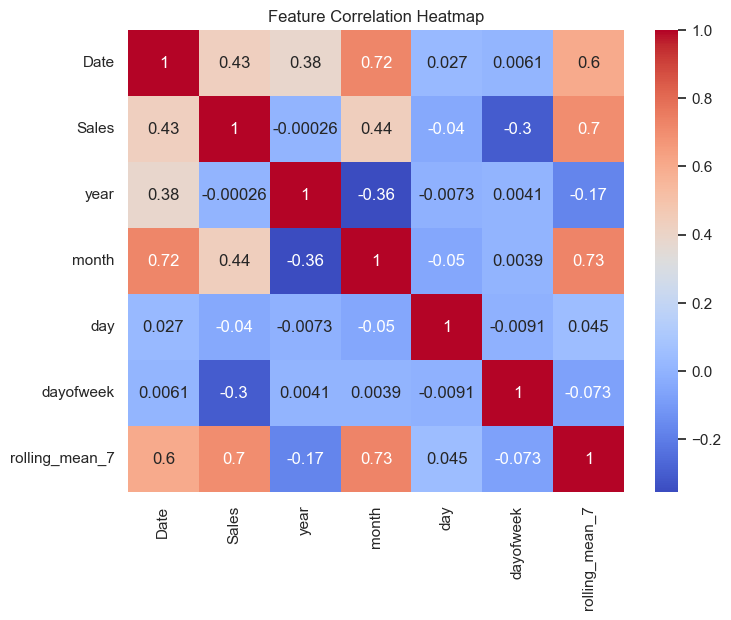

In [80]:

plt.figure(figsize=(8,6))
sns.heatmap(daily_sales.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Seasonal Analysis Heatmap
- The heatmap shows monthly sales trends across different years. It helps identify seasonal demand patterns, which can guide businesses in planning inventory and marketing strategies.

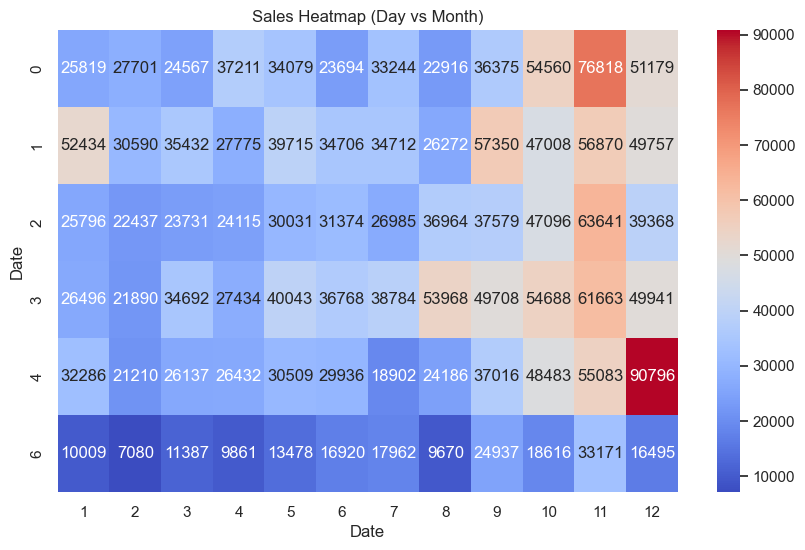

In [81]:
heatmap_week = daily_sales.pivot_table(
    values='Sales',
    index=daily_sales['Date'].dt.dayofweek,
    columns=daily_sales['Date'].dt.month,
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_week, cmap='coolwarm', annot=True, fmt=".0f")

plt.title("Sales Heatmap (Day vs Month)")
plt.show()

## 10. Actual vs Predicted

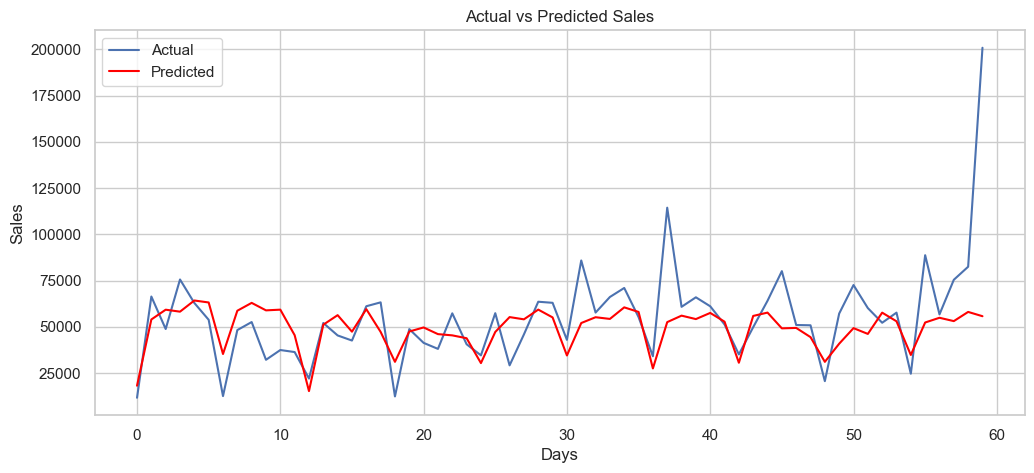

In [82]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted',color='red')
plt.xlabel("Days")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

## 11. Future Forecast

In [83]:
future_dates = pd.date_range(start=daily_sales['Date'].max(), periods=30)

future_df = pd.DataFrame({'Date': future_dates})
future_df['year'] = future_df['Date'].dt.year
future_df['month'] = future_df['Date'].dt.month
future_df['day'] = future_df['Date'].dt.day
future_df['dayofweek'] = future_df['Date'].dt.dayofweek

future_df['rolling_mean_7'] = daily_sales['rolling_mean_7'].iloc[-1]

future_preds = model.predict(future_df[['year','month','day','dayofweek','rolling_mean_7']])

## 12. Forecast Visualization

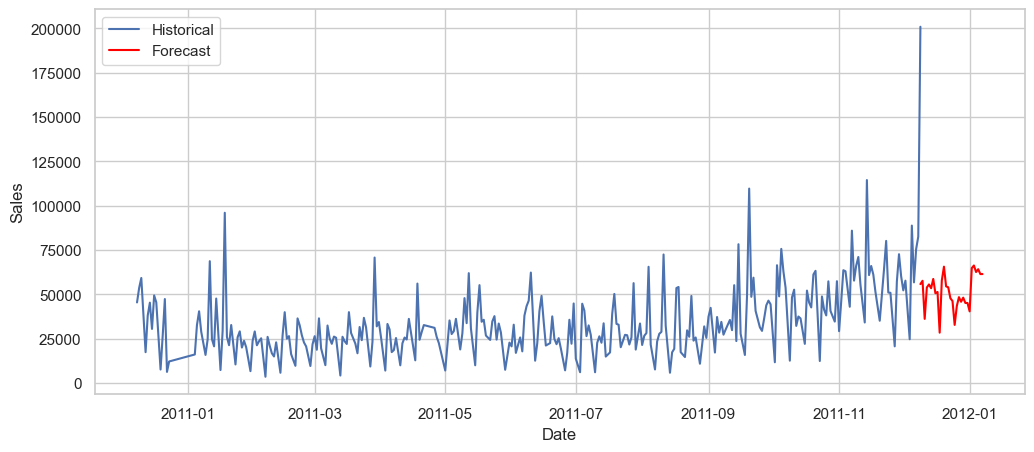

In [84]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Sales', data=daily_sales, label='Historical')
sns.lineplot(x=future_df['Date'], y=future_preds, label='Forecast', color='red')
plt.legend()
plt.show()

## Business Insights

- Sales show clear variation across time, indicating seasonal patterns  
- Demand fluctuates based on days and months  
- The forecasting model predicts stable future demand  

### Business Value:
- Helps in inventory planning  
- Reduces overstocking and stockouts  
- Supports better decision-making  